Name: Aisshwarya Gurav

Roll No.: A_59

PRN: 2324000522

Assignment No. 9 –Stock market prediction using LSTM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 936.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 42.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense
import math
plt.style.use('ggplot')

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 15.2 MB/s eta 0:00:00


In [ ]:
import yfinance as yf
df=yf.download('AAPL',start='2014-06-01',end='2024-06-01')
print(df)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
2014-06-02   19.688835   19.882388   19.496222   19.855141  369350800
2014-06-03   19.967274   20.004858   19.676318   19.682895  292709200
2014-06-04   20.195267   20.291418   19.922476   19.964131  335482000
2014-06-05   20.274515   20.337781   20.126063   20.238498  303805600
2014-06-06   20.218771   20.396980   20.184322   20.354384  349938400
...                ...         ...         ...         ...        ...
2024-05-24  188.348434  188.943288  186.425093  187.198408   36327000
2024-05-28  188.358353  191.342497  187.475997  189.865288   52280100
2024-05-29  188.655777  190.598951  187.882477  187.981624   53068000
2024-05-30  189.647186  190.529542  188.992866  189.121739   49889100
2024-05-31  190.598938  190.916197  188.279038  189.795897   75158300

[2518 rows x 5 columns]


In [ ]:
df.shape

(2518, 5)

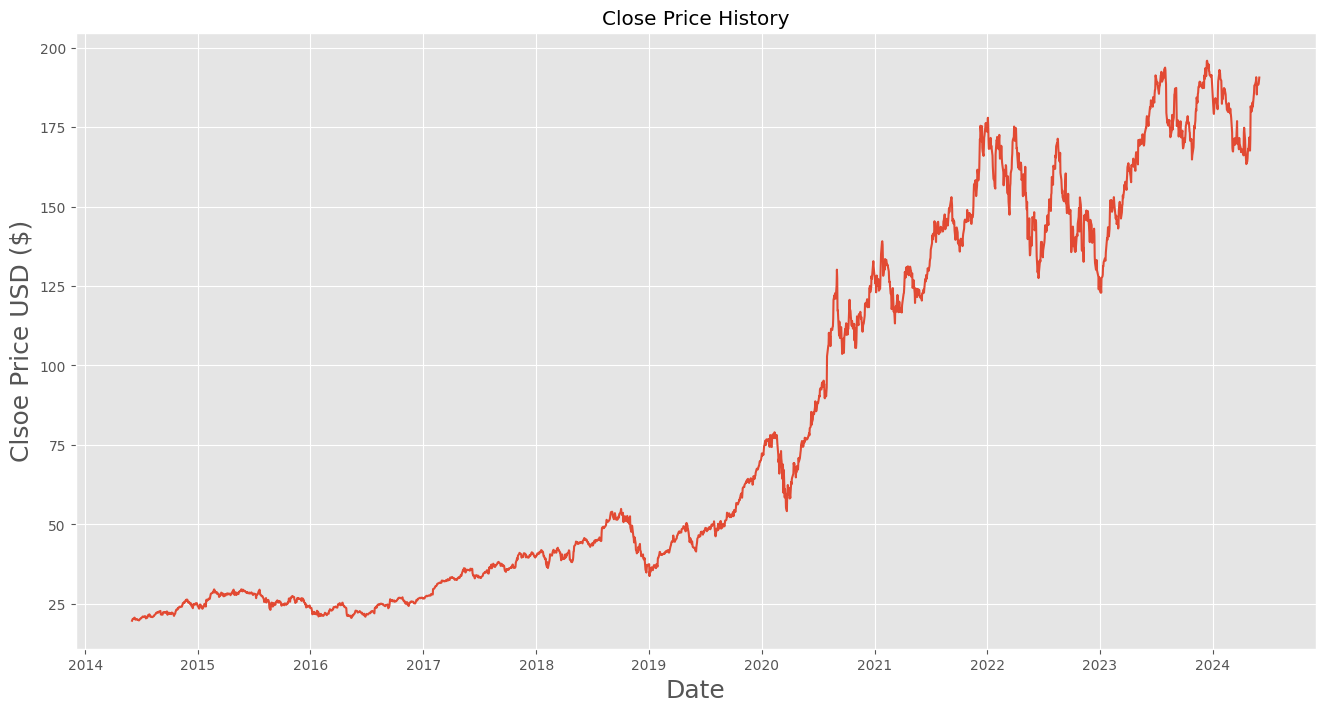

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Clsoe Price USD ($)',fontsize=18)
plt.show()


In [ ]:
# Extract the 'Close' column from the MultiIndex DataFrame.
data = df['Close','AAPL']
# Convert the Series to a NumPy array and reshape it to a 2D column vector.
dataset = data.values.reshape(-1, 1)

training_data_len = math.ceil(len(dataset)*.8)
training_data_len

2015

In [ ]:
ss = MinMaxScaler(feature_range=(0, 1))
scaled_data = ss.fit_transform(dataset)
scaled_data = pd.DataFrame(scaled_data)
scaled_data

,0
0,0.000000
1,0.001580
2,0.002874
3,0.003324
4,0.003008
...,...
2513,0.957185
2514,0.957241
2515,0.958929
2516,0.964556


In [ ]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [ ]:
train_data  = scaled_data.iloc[0:training_data_len,:]
x_train =[]
y_train =[]
for i in range(60,len(train_data)):
    x_train.append(train_data.iloc[i-60:i,0])
    y_train.append(train_data.iloc[i,0])

    if i<=62:
        print(x_train)
        print(y_train)
        print()

[0     0.000000
1     0.001580
2     0.002874
3     0.003324
4     0.003008
5     0.004844
6     0.005528
7     0.005043
8     0.003089
9     0.001833
10    0.002977
11    0.002828
12    0.002952
13    0.002554
14    0.001372
15    0.001273
16    0.000588
17    0.000688
18    0.001360
19    0.002704
20    0.003886
21    0.004620
22    0.004570
23    0.005254
24    0.007668
25    0.006897
26    0.006946
27    0.006511
28    0.006735
29    0.008265
30    0.006859
31    0.006187
32    0.004085
33    0.005752
34    0.005142
35    0.006113
36    0.009186
37    0.008987
38    0.009783
39    0.011463
40    0.010666
41    0.010380
42    0.007208
43    0.007867
44    0.007195
45    0.006610
46    0.006411
47    0.006399
48    0.006724
49    0.008287
50    0.008262
51    0.009850
52    0.010175
53    0.010775
54    0.012251
55    0.013964
56    0.014014
57    0.014026
58    0.014951
59    0.015227
Name: 0, dtype: float64]
[np.float64(0.014413856173232209)]

[0     0.000000
1     0.001580
2     0

In [ ]:
x_train,y_train  = np.array(x_train),np.array(y_train)

In [ ]:
x_train.shape

(1955, 60)

In [ ]:
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train.shape

(1955, 60, 1)

In [ ]:
#input_shape = (timestamp, closing price )

model = Sequential()
model.add(LSTM(50,return_sequences=True, input_shape = (x_train.shape[1],1)))
model.add(LSTM(50,return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer ='Adam', loss= 'mean_squared_error')

In [ ]:
model.fit(x_train,y_train,batch_size=1, epochs=1)

1955/1955 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 0.0012


In [ ]:
test_data = scaled_data.iloc[training_data_len-60:,:]
x_test = []
y_test = dataset[training_data_len -60: , :]
for i in range (60, len(test_data)):
  x_test.append(test_data.iloc[i-60:i,0])

In [ ]:
x_test = np.array(x_test)

In [ ]:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

In [ ]:
predictions = model.predict(x_test)
predictions =ss.inverse_transform(predictions)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [ ]:

y_test_corrected = dataset[training_data_len:, :]
rmse = np.sqrt(np.mean((predictions - y_test_corrected)**2))
rmse


np.float64(11.681316813751303)

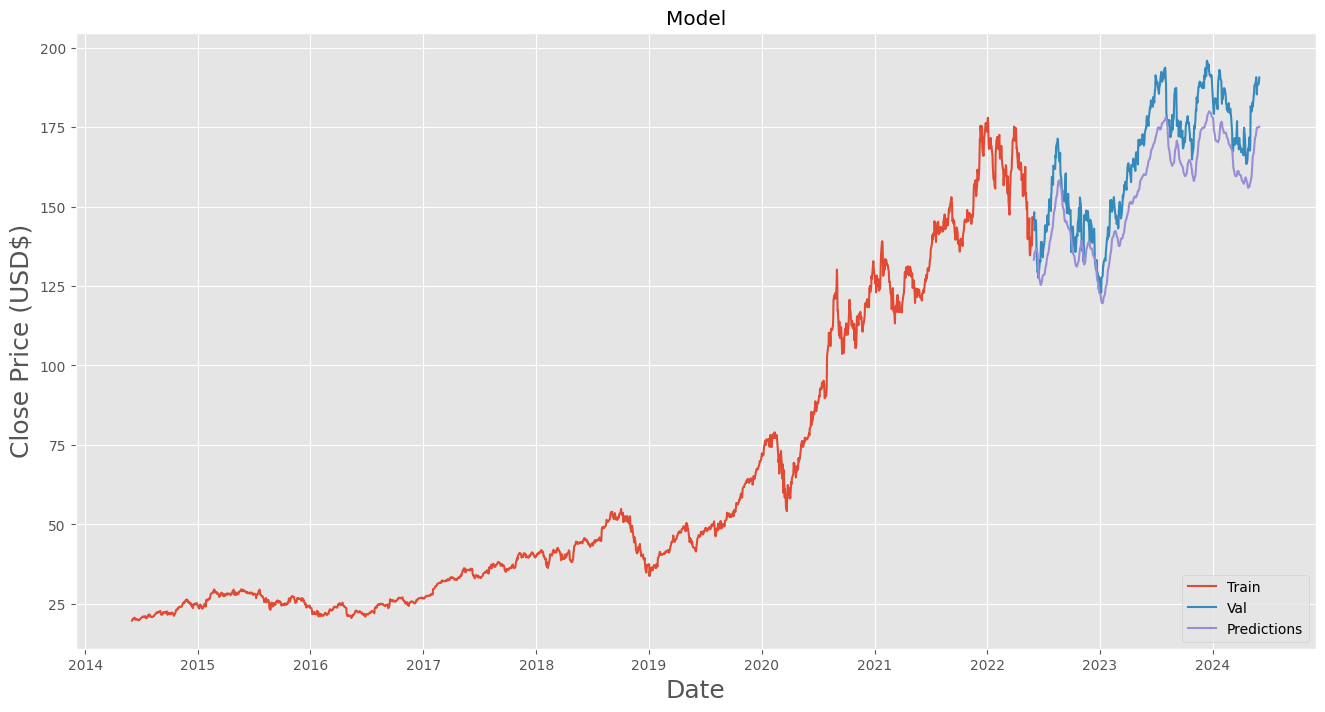

In [ ]:
train = data[:training_data_len]


valid_series = data[training_data_len:]
valid = pd.DataFrame(valid_series)
valid.columns = ['Close']


valid['Predictions '] = predictions.flatten()

plt.figure(figsize=(16,8))
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price (USD$)',fontsize=18)
plt.title('Model')


plt.plot(train.index, train.values, label='Train')


plt.plot(valid.index, valid['Close'], label='Val')
plt.plot(valid.index, valid['Predictions '], label='Predictions')

plt.legend(loc='lower right')
plt.show()

In [ ]:
valid

,Close,Predictions
2022-06-01,145.783524,133.270493
2022-06-02,148.234344,134.303268
2022-06-03,142.519028,135.469925
2022-06-06,143.264130,135.996918
2022-06-07,145.783524,136.222778
...,...,...
2024-05-24,188.348434,174.851822
2024-05-28,188.358353,174.896072
2024-05-29,188.655777,174.936340
2024-05-30,189.647186,174.999420
